<a href="https://colab.research.google.com/github/JuanJ13/Challenge-Telecom-X---I/blob/main/Challenge_TelecomX_Parte1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Challenge Telecom X - Parte I**

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

#📌 Extracción

In [ ]:
df_clientes = pd.read_json('/content/TelecomX_Data.json')
df_clientes

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [ ]:
columnas = list(df_clientes.columns)
columnas

['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']

In [ ]:
df_customer = pd.json_normalize(df_clientes['customer'])
df_phone = pd.json_normalize(df_clientes['phone'])
df_internet = pd.json_normalize(df_clientes['internet'])
df_account = pd.json_normalize(df_clientes['account'])

df_clientes_normalizado = pd.concat([
    df_clientes[['customerID', 'Churn']],
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)

pd.set_option('display.max_columns', None)

In [ ]:
df_clientes_normalizado

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#🔧 Transformación

In [ ]:
df_clientes_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [ ]:
df_clientes_normalizado.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [ ]:
df_clientes_normalizado

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,N/ANN/AoN/A,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,N/ANN/AoN/A,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,N/AYN/AeN/AsN/A,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,N/AYN/AeN/AsN/A,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,N/AYN/AeN/AsN/A,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,N/ANN/AoN/A,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,N/AYN/AeN/AsN/A,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,N/ANN/AoN/A,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,N/ANN/AoN/A,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [ ]:
df_clientes_normalizado['customerID'].unique()

array(['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', ..., '9992-UJOEL',
       '9993-LHIEB', '9995-HOTOH'], dtype=object)

In [ ]:
df_clientes_normalizado['Churn'].unique()

['No' 'Yes' '']


In [ ]:
df_clientes_normalizado['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [ ]:
df_clientes_normalizado['SeniorCitizen'].unique()

array([0, 1])

In [ ]:
df_clientes_normalizado['SeniorCitizen'].unique()

array([0, 1])

In [ ]:
df_clientes_normalizado['Partner'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df_clientes_normalizado['Dependents'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df_clientes_normalizado['tenure'].unique()

array([ 9,  4, 13,  3, 71, 63,  7, 65, 54, 72,  5, 56, 34,  1, 45, 50, 23,
       55, 26, 69, 11, 37, 49, 66, 67, 20, 43, 59, 12, 27,  2, 25, 29, 14,
       35, 64, 39, 40,  6, 30, 70, 57, 58, 16, 32, 33, 10, 21, 61, 15, 44,
       22, 24, 19, 47, 62, 46, 52,  8, 60, 48, 28, 41, 53, 68, 51, 31, 36,
       17, 18, 38, 42,  0])

In [ ]:
df_clientes_normalizado['PhoneService'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df_clientes_normalizado['MultipleLines'].unique()

array(['No', 'Yes', 'No phone service'], dtype=object)

In [ ]:
df_clientes_normalizado['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [ ]:
df_clientes_normalizado['OnlineSecurity'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
df_clientes_normalizado['OnlineBackup'].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [ ]:
df_clientes_normalizado['DeviceProtection'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
df_clientes_normalizado['TechSupport'].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [ ]:
df_clientes_normalizado['StreamingTV'].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [ ]:
df_clientes_normalizado['StreamingMovies'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
df_clientes_normalizado['Contract'].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [ ]:
df_clientes_normalizado['PaperlessBilling'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df_clientes_normalizado['PaperlessBilling'].unique()

In [ ]:
df_clientes_normalizado['Charges.Monthly'].unique()

array([65.6 , 59.9 , 73.9 , ..., 91.75, 68.8 , 67.85])

In [ ]:
df_clientes_normalizado['Charges.Total'].unique()

array(['593.3', '542.4', '280.85', ..., '742.9', '4627.65', '3707.6'],
      dtype=object)

Normalizando la columna de Churn

In [ ]:
df_clientes_normalizado['Churn'] = df_clientes_normalizado['Churn'].replace(' ', 'N/A')

In [ ]:
df_clientes_normalizado['Churn'].unique()

array(['No', 'Yes', 'N/A'], dtype=object)

In [ ]:
df_clientes_normalizado

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [ ]:
df_clientes_normalizado['Cuentas_Diarias'] = df_clientes_normalizado['Charges.Monthly'] / 30

In [ ]:
df_clientes_normalizado

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [ ]:
df_clientes_normalizado.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias'],
      dtype='object')

#📊 Carga y análisis

In [ ]:
df_clientes_normalizado.describe()

,SeniorCitizen,tenure,Charges.Monthly,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098,2.157337
std,0.369074,24.571773,30.129572,1.004319
min,0.000000,0.000000,18.250000,0.608333
25%,0.000000,9.000000,35.425000,1.180833
50%,0.000000,29.000000,70.300000,2.343333
75%,0.000000,55.000000,89.875000,2.995833
max,1.000000,72.000000,118.750000,3.958333


##Variables categoricas

/tmp/ipykernel_423/3128836032.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_grafico, x='Churn', palette='RdBu')


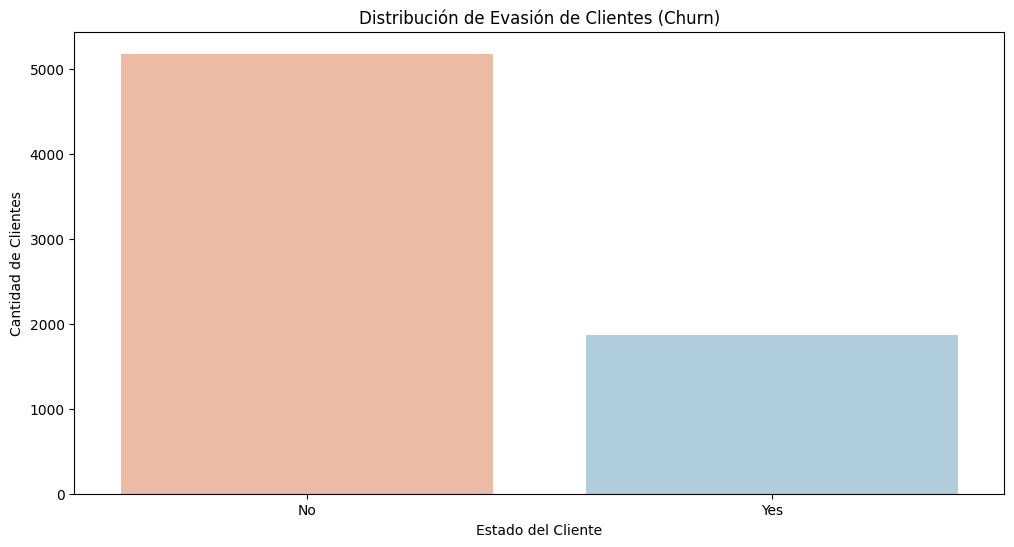

In [ ]:
df_grafico = df_clientes_normalizado[df_clientes_normalizado['Churn'] != 'N/A']



plt.figure(figsize=(12, 6))
sns.countplot(data=df_grafico, x='Churn', palette='RdBu')

plt.title('Distribución de Evasión de Clientes (Churn)')
plt.xlabel('Estado del Cliente')
plt.ylabel('Cantidad de Clientes')
plt.show()

El resultado de la anterior gráfica es: No, corresponde a las personas que no abandonaron el servicio y Yes los que abandonaron el servicio

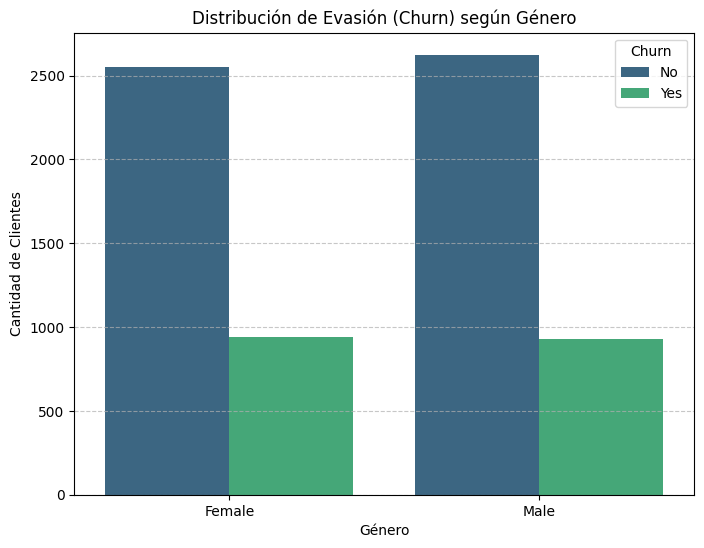

In [ ]:
df_grafico = df_clientes_normalizado[df_clientes_normalizado['Churn'] != 'N/A']


plt.figure(figsize=(8, 6))
sns.countplot(data=df_grafico, x='gender', hue='Churn', palette='viridis')


plt.title('Distribución de Evasión (Churn) según Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de Clientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

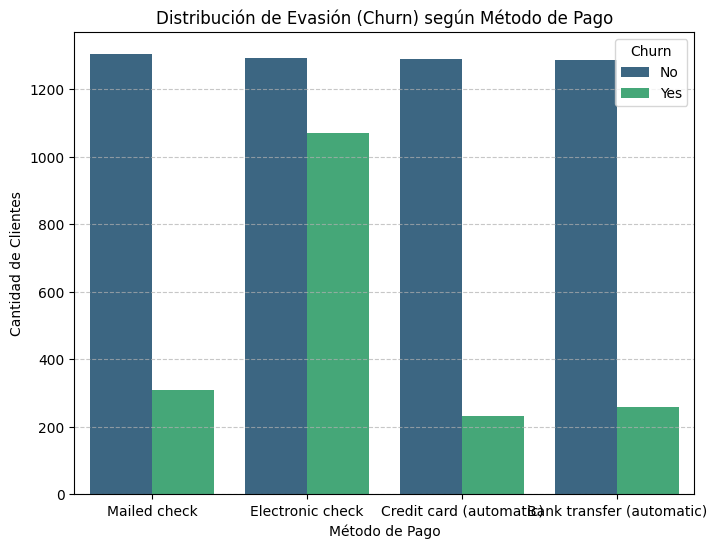

In [ ]:
df_grafico = df_clientes_normalizado[df_clientes_normalizado['Churn'] != 'N/A']


plt.figure(figsize=(8, 6))
sns.countplot(data=df_grafico, x='PaymentMethod', hue='Churn', palette='viridis')


plt.title('Distribución de Evasión (Churn) según Método de Pago')
plt.xlabel('Método de Pago')
plt.ylabel('Cantidad de Clientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

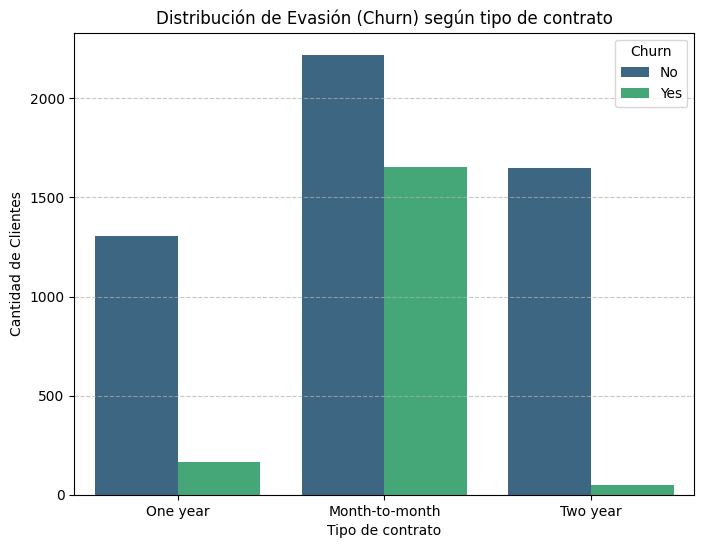

In [ ]:
df_grafico = df_clientes_normalizado[df_clientes_normalizado['Churn'] != 'N/A']


plt.figure(figsize=(8, 6))
sns.countplot(data=df_grafico, x='Contract', hue='Churn', palette='viridis')


plt.title('Distribución de Evasión (Churn) según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de Clientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

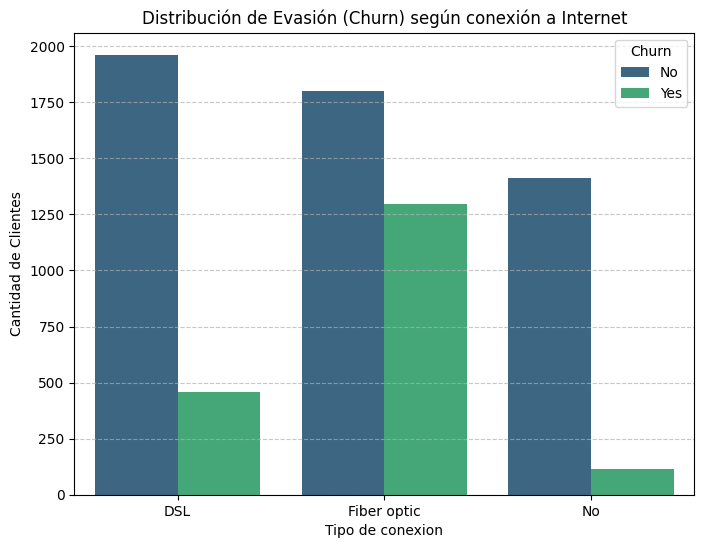

In [ ]:
df_grafico = df_clientes_normalizado[df_clientes_normalizado['Churn'] != 'N/A']


plt.figure(figsize=(8, 6))
sns.countplot(data=df_grafico, x='InternetService', hue='Churn', palette='viridis')

plt.title('Distribución de Evasión (Churn) según conexión a Internet')
plt.xlabel('Tipo de conexion')
plt.ylabel('Cantidad de Clientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##Variables numéricas

/tmp/ipykernel_423/3127401965.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_grafico, x='Churn', y='tenure', palette='Set2')


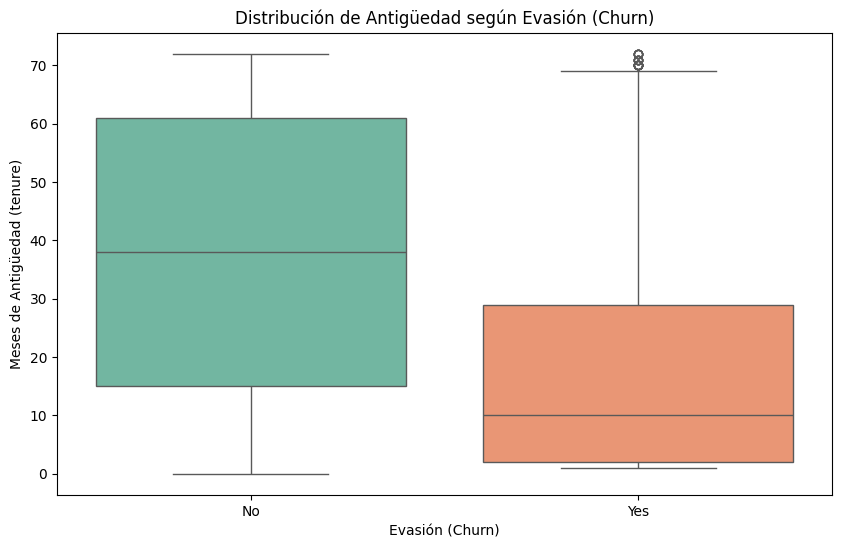

In [ ]:
df_grafico = df_clientes_normalizado[df_clientes_normalizado['Churn'] != 'N/A']

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_grafico, x='Churn', y='tenure', palette='Set2')

plt.title('Distribución de Antigüedad según Evasión (Churn)')
plt.xlabel('Evasión (Churn)')
plt.ylabel('Meses de Antigüedad (tenure)')
plt.show()

/tmp/ipykernel_423/358805415.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_grafico, x='Churn', y='Charges.Monthly', palette='Set2')


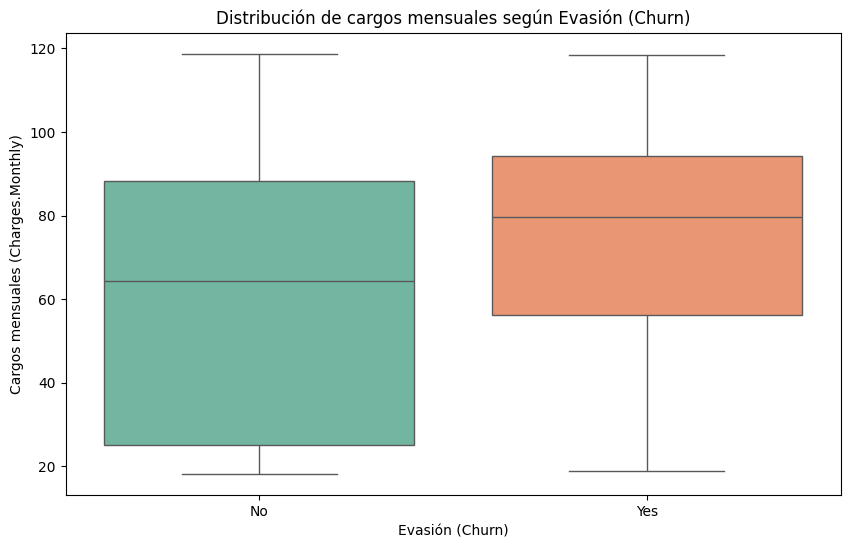

In [ ]:
df_grafico = df_clientes_normalizado[df_clientes_normalizado['Churn'] != 'N/A']

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_grafico, x='Churn', y='Charges.Monthly', palette='Set2')

plt.title('Distribución de cargos mensuales según Evasión (Churn)')
plt.xlabel('Evasión (Churn)')
plt.ylabel('Cargos mensuales (Charges.Monthly)')
plt.show()

/tmp/ipykernel_423/3513765953.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_grafico, x='Churn', y='Charges.Total', palette='Set2')


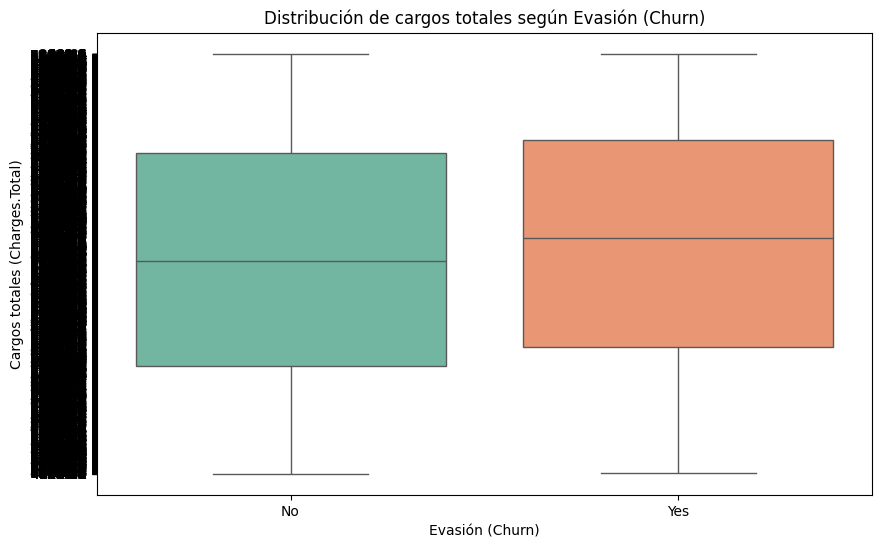

In [ ]:
df_grafico = df_clientes_normalizado[df_clientes_normalizado['Churn'] != 'N/A']

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_grafico, x='Churn', y='Charges.Total', palette='Set2')

plt.title('Distribución de cargos totales según Evasión (Churn)')
plt.xlabel('Evasión (Churn)')
plt.ylabel('Cargos totales (Charges.Total)')
plt.show()

#📄Informe final

El objetivo principal de este trabajo fue comprender las razones detrás de la evasión de clientes en Telecom X, especialmente ante la observación reciente de usuarios que decidían cancelar sus servicios sin una causa clara. Para comenzar, importamos el dataset proporcionado por la empresa utilizando la biblioteca **Pandas**. Dado que los datos contenían diccionarios anidados, fue necesario normalizar las columnas para obtener un formato tabular legible. Tras validar los tipos de datos y asegurar que el DataFrame estuviera correctamente estructurado, utilizamos el atributo .unique() para realizar una auditoría exhaustiva. Detectamos valores faltantes en la columna **Churn**, los cuales decidimos etiquetar como **N/A** para mantener la trazabilidad de los registros y optimizar las visualizaciones futuras.

Posteriormente, realizamos una exploración macro de los datos mediante la función *describe()*, lo que nos permitió visualizar las tendencias centrales de las variables numéricas. Para profundizar, empleamos las bibliotecas **Matplotlib** y **Seaborn** en la creación de gráficos detallados. En el caso de las variables categóricas, generamos diagramas de barras de la columna **Churn** para comparar el volumen de usuarios que permanecen frente a quienes se van, contrastando esta información con variables como **gender, PaymentMethod y Contract**. Para las variables numéricas, utilizamos diagramas de caja para analizar el comportamiento de **tenure, Charges.Monthly y Charges.Total** en relación con la evasión.

A partir de los hallazgos, concluimos que la mayoría de los clientes permanece en la empresa, pero existe una tasa de fuga preocupante que requiere atención. Identificamos que el **método de pago electrónico** es un factor crítico, ya que más de 1,000 clientes que abandonaron el servicio utilizaban esta modalidad. Asimismo, la variable de **conexión a internet** incide significativamente en la decisión, con más de 1,250 clientes con servicio de **fibra óptica** que desistieron del servicio, lo cual apunta a posibles problemas de calidad. Finalmente, el análisis de antigüedad reveló que quienes abandonan la empresa tienen, en promedio, menos de 10 meses de permanencia, lo que explica esta fuga temprana.

Ante estos resultados, se recomienda afinar los procesos operativos en el apartado de **pagos digitales** y realizar una auditoría técnica profunda sobre la calidad del servicio de** fibra óptica**. Es fundamental implementar estrategias de fidelización durante los primeros meses de relación contractual, buscando que el promedio de **tenure** aumente y garantice así la permanencia de muchos más clientes a largo plazo.